# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaiAlhusseini/FlyRank_Intern_repo/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

Each row represents one content page. The analysis is performed over a historical performance window using aggregated content and engagement metrics collected over the available observation period. The model will use past information to prioritize pages for refresh review.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv


In [3]:
import pandas as pd

df = pd.read_csv("content_refresh_anonymized.csv")

df.shape
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

The model will use historical content and search performance signals available before making a refresh decision. These features help estimate which pages have higher refresh opportunities.
Features used:

search_volume → indicates the potential search demand for the topic.

competition and competition_level → represent how competitive the keyword space is.

content_type and main_intent → describe the type and purpose of the content.

word_count and char_count → represent content size.

impressions_90d, clicks_90d, pageviews_90d, sessions_90d, users_90d → represent historical performance.

impressions_last_30d, clicks_last_30d, sessions_last_30d → represent recent performance.

impressions_prev_30d, clicks_prev_30d, sessions_prev_30d → allow comparison between recent and previous performance.

content_age_days and days_since_last_update → represent freshness.

ctr, avg_position, engagement_rate, scroll_rate → represent user engagement and search performance.

trend_pct and trend_direction → represent performance changes over time.

The target is a content refresh priority score that ranks pages based on their opportunity for review.
The goal is not to predict an existing human decision, but to estimate which pages should be prioritized using observed performance signals such as traffic decline, aging content, and engagement changes.

Context

These fields provide information about the content but are mainly used for interpretation:

content_id → identifies each content page.

client_id → identifies the associated client.

age_tier and freshness_tier → summarize content age/freshness.

word_count_tier and char_count_tier → categorize content length.

impression_tier and position_tier → summarize search performance categories.

Excluded

The following fields are excluded from model training:

provider_used
model_used

Why: They describe how content was generated, not the content opportunity itself.

content_id
client_id

Why: They are identifiers and do not contain useful learning patterns.

Manually created tier columns such as:age_tier
freshness_tier
word_count_tier
impression_tier
position_tier

Why: They are derived summaries of other variables and may duplicate information already available.

In [4]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

The dataset contains one row per content item (content_id). Historical performance is aggregated over predefined periods, including 90-day metrics, the last 30 days, and the previous 30 days. I verified the dataset structure by checking the dataset size, duplicate content IDs, missing values, and the available time-window fields.

In [11]:
# Dataset shape
print("\nDataset Shape:", df.shape)
print("-----------------------------------------------------------------")
# unique content IDs
print("\nUnique IDs:", df["content_id"].nunique())
print("-----------------------------------------------------------------")
# unique values
print("\nUnique content :", df.nunique())
print("-----------------------------------------------------------------")
# duplicate content IDs
print("\nDuplicate content IDs:", df["content_id"].duplicated().sum())
print("-----------------------------------------------------------------")
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())
print("-----------------------------------------------------------------")
# Verify available time windows
print("\nTime Window Columns:")
time_columns = [
    "impressions_90d", "clicks_90d", "sessions_90d",
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
    "days_with_impressions", "days_with_sessions"
]

print(df[time_columns].describe())


Dataset Shape: (30000, 44)
-----------------------------------------------------------------

Unique IDs: 30000
-----------------------------------------------------------------

Unique content : content_id                30000
client_id                    32
search_volume                41
competition                 101
competition_level             3
cpc                         915
content_type                  3
main_intent                   4
word_count                 5476
char_count                14839
provider_used                 2
model_used                    5
impressions_90d            9438
clicks_90d                  477
pageviews_90d               856
sessions_90d                666
users_90d                   644
engaged_sessions_90d         68
ai_sessions_90d              35
scroll_events_90d           155
days_with_impressions        88
days_with_sessions           90
impressions_last_30d       5182
clicks_last_30d             239
sessions_last_30d           359
imp

## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

This dataset contains aggregated historical performance metrics over fixed periods (90 days, last 30 days, and previous 30 days). While it is useful for identifying pages that may need a content refresh, it has several limitations:

- It cannot explain *why* performance changed, only that it changed.
- It does not include qualitative information such as content quality, readability, or factual accuracy.
- It does not account for external factors such as Google algorithm updates, seasonality, or competitor activity.
- Some pages may have limited historical data (e.g., fewer days with impressions or sessions), making comparisons less reliable.
- Historical trends may not always predict future performance, so refresh decisions should also include human review.

In [12]:
# Missing values percentage
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

print("Missing Values (%):")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

# Check pages with limited history
print("\nPages with fewer than 90 days of impressions:")
print((df["days_with_impressions"] < 90).sum())

print("\nPages with fewer than 90 days of sessions:")
print((df["days_with_sessions"] < 90).sum())

# Trend distribution
print("\nTrend Direction Distribution:")
print(df["trend_direction"].value_counts())

# Content age summary
print("\nContent Age Summary:")
print(df["content_age_days"].describe())


Missing Values (%):
provider_used        71.46
word_count_tier      25.66
char_count           25.66
word_count           25.66
char_count_tier      25.66
model_used           19.11
trend_pct            11.29
competition_level     8.70
search_volume         8.23
competition           8.23
cpc                   8.23
main_intent           7.91
scroll_rate           0.42
dtype: float64

Pages with fewer than 90 days of impressions:
30000

Pages with fewer than 90 days of sessions:
29982

Trend Direction Distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Content Age Summary:
count    30000.00000
mean       256.16780
std        132.70793
min         90.00000
25%        132.00000
50%        236.00000
75%        333.00000
max        564.00000
Name: content_age_days, dtype: float64


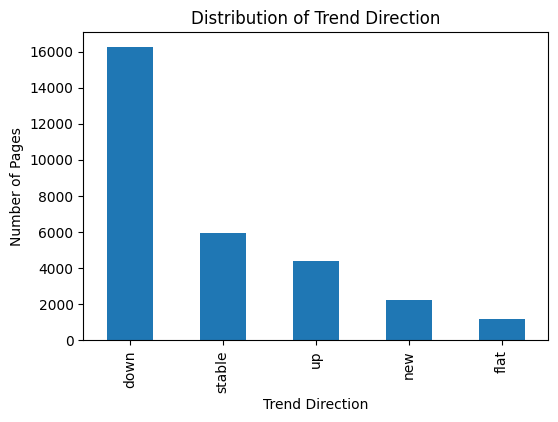

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))

df["trend_direction"].value_counts().plot(kind="bar")

plt.title("Distribution of Trend Direction")
plt.xlabel("Trend Direction")
plt.ylabel("Number of Pages")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.